<a href="https://colab.research.google.com/github/AIPI510/aipi510-fall26/blob/daniel-week4/data_explore_daniel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Welltory COVID-19 and Wearables Data Exploration

**Name:** Daniel Yaari

## Dataset Context



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [53]:
print(open("/content/hrv-covid19/README.md").read())

# Welltory COVID-19 and Wearables Open Data Research

![Welltory Research objective](https://i.imgur.com/LZtUXuu.jpg)

The open COVID-19 research was carried out in 2020 year by the Welltory team to detect patterns regarding the COVID-19 disease; progression and recovery.

As part of the research, our users with positive COVID-19 status tracked their symptoms, heart rate variability, and data with the [Welltory app](https://welltory.com).

We have organized open research on a non-commercial basis because we believe that only all together we can fight the COVID-19 pandemic.

#### We collected:

1. **Heart rate variability measurements.** Measurements were made with any Bluetooth-enabled heart rate monitor or with a smartphone camera with a high resolution - a method called Photoplethysmography (PPG). It is a simple optical technique used to detect blood volume changes in the microvascular bed of tissue to track the heartbeat. To read more about PPG - look into Welltory’s research [Smart

My analysis will focus on key physiological and self-reported features:

* rmssd: Short-term heart rate variability (HRV), measured in milliseconds (ms).
* bpm / sdnn: Heart rate.
* how_sleep: Self-reported sleep quality score (-2 to +2).
* how_mood / how_feel: Self-reported mood and physical wellbeing (-2 to +2).
* measurement_datetime / time_of_day: When each HRV measurement was recorded.
* user_code: Anonymous participant identifier.


In [3]:
!git clone https://github.com/Welltory/hrv-covid19.git

Cloning into 'hrv-covid19'...
remote: Enumerating objects: 198, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 198 (delta 5), reused 4 (delta 1), pack-reused 186 (from 1)
Receiving objects: 100% (198/198), 4.57 MiB | 8.92 MiB/s, done.
Resolving deltas: 100% (128/128), done.


In [4]:
participants = pd.read_csv("/content/hrv-covid19/data/participants.csv")

hrv = pd.read_csv("/content/hrv-covid19/data/hrv_measurements.csv")

In [7]:
participants.shape

(185, 8)

In [8]:
hrv.shape

(3245, 22)

In [9]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_code       185 non-null    object 
 1   gender          185 non-null    object 
 2   age_range       185 non-null    object 
 3   city            173 non-null    object 
 4   country         179 non-null    object 
 5   height          183 non-null    float64
 6   weight          185 non-null    float64
 7   symptoms_onset  147 non-null    object 
dtypes: float64(2), object(6)
memory usage: 11.7+ KB


In [10]:
hrv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3245 entries, 0 to 3244
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_code             3245 non-null   object 
 1   rr_code               3245 non-null   object 
 2   measurement_datetime  3245 non-null   object 
 3   time_of_day           3245 non-null   object 
 4   bpm                   3245 non-null   int64  
 5   meanrr                3245 non-null   float64
 6   mxdmn                 3245 non-null   float64
 7   sdnn                  3245 non-null   float64
 8   rmssd                 3245 non-null   float64
 9   pnn50                 3245 non-null   float64
 10  mode                  3245 non-null   float64
 11  amo                   3245 non-null   float64
 12  lf                    3245 non-null   float64
 13  hf                    3245 non-null   float64
 14  vlf                   3245 non-null   float64
 15  lfhf                 

In [11]:
participants.isnull().sum()

,0
user_code,0
gender,0
age_range,0
city,12
country,6
height,2
weight,0
symptoms_onset,38


In [19]:
#Check what percent of data is missing in participants
(participants.isnull().sum() / participants.shape[0]) * 100

,0
user_code,0.000000
gender,0.000000
age_range,0.000000
city,6.486486
country,3.243243
height,1.081081
weight,0.000000
symptoms_onset,20.540541


In [18]:
#Missing vals in hrv
(hrv.isnull().sum() / hrv.shape[0]) * 100

,0
user_code,0.000000
rr_code,0.000000
measurement_datetime,0.000000
time_of_day,0.000000
bpm,0.000000
meanrr,0.000000
mxdmn,0.000000
sdnn,0.000000
rmssd,0.000000
pnn50,0.000000


In [17]:
#participants duplicates
participants.duplicated().sum()

np.int64(0)

In [20]:
#hrv duplicates
hrv.duplicated().sum()

np.int64(0)

In [21]:
participants["user_code"].nunique()

185

In [22]:
hrv["user_code"].nunique()

185

In [23]:
participants["user_code"].isin(hrv["user_code"]).sum()

np.int64(185)

Same subjects in data!

In [24]:
participants.describe()

,height,weight
count,183.000000,185.000000
mean,169.976393,77.927757
std,12.400103,19.552541
min,132.080000,43.500000
25%,163.500000,63.500000
50%,168.000000,74.344000
75%,174.500000,90.537000
max,250.000000,154.221000


outlier of 250 in height is worth noting due to mean and median being roughly equal at 169.

In [26]:
participants[participants["height"] > 200]

,user_code,gender,age_range,city,country,height,weight,symptoms_onset
49,3fff7627ca,m,35-44,Fountain Hill,United States,248.92,114.713,4/5/1984
83,6ce06ce747,m,35-44,St Petersburg,Russia,203.00,70.534,NaN
102,83161408c1,m,25-34,Kurdistan,Iraq,250.00,82.146,1/1/1993


$$ Q3 + 1.5(IQR) $$

For our upper limit:

174.5+1.5(11)=191

The three subjects may be incorrectly inputted.

In [27]:
hrv[["bpm", "sdnn", "rmssd"]].describe()

,bpm,sdnn,rmssd
count,3245.000000,3245.000000,3245.000000
mean,73.257935,52.489218,52.814196
std,12.201088,29.369506,39.353213
min,44.000000,9.515000,6.340000
25%,65.000000,32.585000,28.985000
50%,72.000000,46.919000,42.869000
75%,81.000000,64.406000,62.485000
max,125.000000,206.631000,310.800000


BPM: median 72 & mean 73.3 means data is centered
SDNN: median 46.9 & mean 52.5 but has a max 206.6 meaning there are some high-end values and obvious outliers.
RMSSD: median 42.9 << mean 52.8 with a max 310.8. Super right-skewed / extreme

In [28]:
hrv.value_counts("how_mood")

,count
how_mood,
0,2335
-1,471
1,272
-2,96
2,71


Has a scale of horrible (-2) up to amazing (+2) with a neutral score in the middle (0). 72% of participants are at a 0 score.

In [33]:
hrv[["measurement_datetime", "time_of_day", "rmssd", "how_sleep"]].head(10)

,measurement_datetime,time_of_day,rmssd,how_sleep
0,2020-04-21 21:23:08,morning,54.174,NaN
1,2020-04-26 11:19:25,morning,33.022,0.0
2,2020-05-15 04:14:21,night,65.987,NaN
3,2020-05-19 03:06:02,night,70.039,NaN
4,2019-12-31 09:07:43,morning,21.196,0.0
5,2020-01-11 14:52:39,day,20.753,NaN
6,2020-01-30 17:55:54,day,22.525,NaN
7,2020-04-02 12:07:09,day,24.118,NaN
8,2020-04-12 15:00:58,day,28.472,NaN
9,2020-04-13 19:17:50,day,28.847,NaN


In [34]:
hrv["how_sleep"].value_counts()

,count
how_sleep,
0.0,967
-1.0,238
1.0,180
-2.0,50
2.0,31


Same idea as "how_mood" with a -2 to +2 scale

In [35]:
hrv.groupby("time_of_day")["how_sleep"].count()

,how_sleep
time_of_day,
day,25
evening,0
morning,1440
night,1


In [36]:
hrv.groupby("time_of_day")["how_mood"].count()

,how_mood
time_of_day,
day,806
evening,701
morning,1467
night,271


In [37]:
hrv.groupby("how_sleep")["how_mood"].count()

,how_mood
how_sleep,
-2.0,50
-1.0,238
0.0,967
1.0,180
2.0,31


In [38]:
hrv[["how_sleep", "how_mood", "how_feel"]].corr()

,how_sleep,how_mood,how_feel
how_sleep,1.000000,0.519796,0.599439
how_mood,0.519796,1.000000,0.633266
how_feel,0.599439,0.633266,1.000000


In [39]:
morning_hrv = hrv[hrv["time_of_day"] == "morning"]

In [40]:
morning_hrv.groupby("how_sleep")["rmssd"].mean()

,rmssd
how_sleep,
-2.0,46.847500
-1.0,61.493043
0.0,56.460525
1.0,57.949040
2.0,52.751258


In [41]:
morning_hrv.groupby("how_sleep")["rmssd"].count()

,rmssd
how_sleep,
-2.0,50
-1.0,231
0.0,951
1.0,177
2.0,31


In [42]:
morning_hrv[morning_hrv["how_sleep"] == -2]["rmssd"]

,rmssd
126,58.103
155,57.258
211,52.606
570,8.340
660,69.087
679,42.749
690,166.994
740,62.683
743,21.646
760,20.631


Huge amount of data concentrated here with a large variation. Ideal for a box plot here!

Complete: Explore data visually with appropriate visualizations

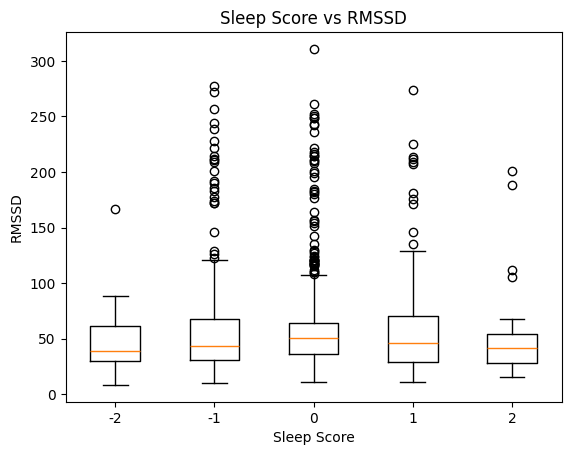

In [44]:
rmssd_groups = []
sleep_scores = [-2, -1, 0, 1, 2]

for score in sleep_scores:
    values = morning_hrv[morning_hrv["how_sleep"] == score]["rmssd"]
    rmssd_groups.append(values)

plt.boxplot(rmssd_groups)
plt.xlabel("Sleep Score")
plt.ylabel("RMSSD (ms)")
plt.title("Sleep Score vs RMSSD")
plt.xticks(range(1, 6), sleep_scores)
plt.show()

Morning RMSSD does not show a clear relationship with self-reported sleep score (I had infered differently). Median RMSSD is highest for a sleep score of 0, while the distributions overlap substantially. Numerous RMSSD outliers are also present, particulary high-tailed. Because the sleep-score groups are highly imbalanced, this comparison is not the best measurment to take nor should I consider any correlation in the data.

Complete: "Perform data transformation as appropriate"

In [45]:
hrv["measurement_datetime"].dtype

dtype('O')

In [46]:
hrv["measurement_datetime"] = pd.to_datetime(hrv["measurement_datetime"])

In [47]:
hrv["measurement_datetime"].dtype

dtype('<M8[ns]')

Complete: Create at least one new feature and document your approach. Here I will take the column I transformed ("measurement_datetime") to have a new column that only has the hour of the day to create more segmented data.

In [49]:
hrv["time_hour"] = hrv["measurement_datetime"].dt.hour

In [50]:
hrv[["measurement_datetime", "time_hour"]].head(10)

,measurement_datetime,time_hour
0,2020-04-21 21:23:08,21
1,2020-04-26 11:19:25,11
2,2020-05-15 04:14:21,4
3,2020-05-19 03:06:02,3
4,2019-12-31 09:07:43,9
5,2020-01-11 14:52:39,14
6,2020-01-30 17:55:54,17
7,2020-04-02 12:07:09,12
8,2020-04-12 15:00:58,15
9,2020-04-13 19:17:50,19


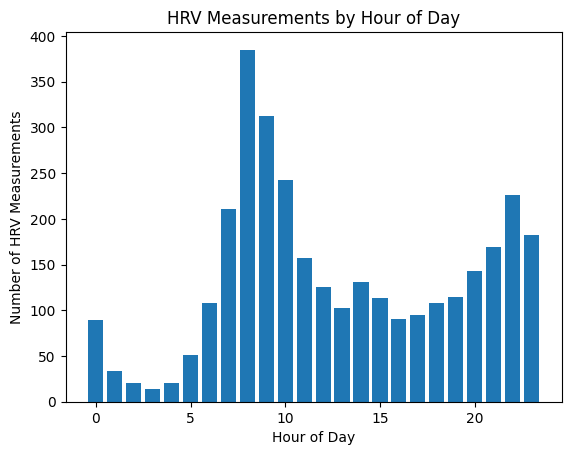

In [51]:
hour_counts = hrv["time_hour"].value_counts().sort_index()

plt.bar(hour_counts.index, hour_counts.values)
plt.xlabel("Hour of Day")
plt.ylabel("Number of HRV Measurements")
plt.title("HRV Measurements by Hour of Day")
plt.show()

There is a large skew in when data was entered by subjects. This can be a leading justification why mood levels and energy levels varied greatly. Further testing should be done where these surveys are collected at the same time.

In [52]:
hrv["rr_code"].nunique()

3245

Complete: Each measurement has a unique identifier and finds no duplicates. This shows data integrity!

Missing-value & outliers: Missing values were retained rather than dropped or imputed. Because missingness was concentrated in optional or self-reported variables (where the data was not utalized), imputing them could introduce unsupported values and dropping all incomplete rows would unnecessarily remove a substantial portion of good physiological measurements.
 Outliers were identified through statistics and visuals. Extreme RMSSD values were kept because statistical outliers are not necessarily measurement errors, and there was insufficient evidence to classify them as invalid (nor do I truly understand the metric system...).

Data Accuracy: Descriptive statistics were used to identify potentially inaccurate or implausible values. Participant heights included extreme values near 249–250 cm, which were flagged as potential accuracy concerns. However, as mentioned in the outliers, these observations were not removed because their validity could not be confirmed.

Data Consistency: Variable formats and categorical usage were reviewed for consistency in the beginning of the assignment. Self-reported sleep scores were strongly concentrated in measurements labeled as morning: 1,440 of the 1,466 non-missing how_sleep observations occurred in the morning category. This is consistent with the interpretation of how_sleep as a retrospective sleep assessment.
I did notice and change one data type found in the set. The "measurement_datetime" field was converted from an object to a datetime datatype to ensure temporal processing.

Data Lineage and Provenance: The data used in this analysis were obtained from Welltory's public hrv-covid19 GitHub repository. The CSV files were cloned into the Google Colab environment and were NOT modified directly. All cleaning, filtering, transformations, and feature engineering were performed within the notebook, preserving the original source data. This will then be uploaded to week-4 branch via daniel-week4.

The Welltory team collected data, as mentioned in the README, like this:

"1. **Heart rate variability measurements.** Measurements were made with any Bluetooth-enabled heart rate monitor or with a smartphone camera with a high resolution - a method called Photoplethysmography (PPG). It is a simple optical technique used to detect blood volume changes in the microvascular bed of tissue to track the heartbeat. To read more about PPG - look into Welltory’s research [Smartphone PPG: signal processing, quality assessment, and impact on HRV parameters](https://ieeexplore.ieee.org/document/8856540). To know how Welltory preprocesses signals, follow our research [Wavelet Analysis And Self-Similarity Of Photoplethysmography Signals For HRV Estimation And Quality Assessment](https://www.mdpi.com/1424-8220/21/20/6798)

2. **Data from user-connected gadgets** including devices such as Apple Watch and Garmin that sync with Google Fit or Apple Health.

3. **Clinically validated physical and mental health assessments.** We created a feature specifically for this project, where people would add information about symptoms and test results.

We released a collected data set to researchers were to study patterns which ought to predict symptoms. The Welltory team is now happy to announce that this data is accessible to anyone who seeks to do scientific research."

~Welltory team, 2020
